In [52]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [53]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

store_sales_time_series_forecasting_path = kagglehub.competition_download('store-sales-time-series-forecasting')

print('Data source import complete.')


Data source import complete.


#### Notes
- change Datetime data type.
- Join every data sets with both train and test.
- Clean data.
- Feature engeenering on categorical columns.
- 43 null value in oil price can be filled with forward fill or backword fill.
- convert date type in holiday column.  

In [54]:
# --- import libreries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [55]:
# --- import data sets ---
import pandas as pd
import os

train = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "train.csv"))
test = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "test.csv"))
stores = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "stores.csv"))
oil = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "oil.csv"))
transactions = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "transactions.csv"))
holidays = pd.read_csv(os.path.join(store_sales_time_series_forecasting_path, "holidays_events.csv"))

### Make it ready to explore

In [56]:
print(train.head())
print("====================================================================\n")
print(stores.head())
print("====================================================================\n")
print(oil.head())
print("====================================================================\n")
print(holidays.head())
print("====================================================================\n")
print(test.head())
print("====================================================================\n")
print(transactions.head())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20

         date     type    local

In [57]:
# --- train ---
print(train.info())
print('=====================================\n')
print(train.describe())
print('=====================================\n')
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None

                 id     store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06  3.000888e+06
mean   1.500444e+06  2.750000e+01  3.577757e+02  2.602770e+00
std    8.662819e+05  1.558579e+01  1.101998e+03  1.221888e+01
min    0.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00
25%    7.502218e+05  1.400000e+01  0.000000e+00  0.000000e+00
50%    1.500444e+06  2.750000e+01  1.100000e+01  0.000000e+00
75%    2.250665e+06  4.100000e+01  1.958473e+02  0.000000e+00
max    3.000887e+06  5.400000e+01  1.247170e+05  7.410000e+02

id             0
date           0
store_nbr      0


In [58]:
# --- stores ---
print(stores.info())
print('=====================================\n')
print(stores.describe())
print('=====================================\n')
print(stores.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None

       store_nbr    cluster
count  54.000000  54.000000
mean   27.500000   8.481481
std    15.732133   4.693395
min     1.000000   1.000000
25%    14.250000   4.000000
50%    27.500000   8.500000
75%    40.750000  13.000000
max    54.000000  17.000000

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


In [59]:
print(oil.info())
print('=====================================\n')
print(oil.describe())
print('=====================================\n')
print(oil.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB
None

        dcoilwtico
count  1175.000000
mean     67.714366
std      25.630476
min      26.190000
25%      46.405000
50%      53.190000
75%      95.660000
max     110.620000

date           0
dcoilwtico    43
dtype: int64


In [60]:
print(holidays.info())
print('=====================================\n')
print(holidays.describe())
print('=====================================\n')
print(holidays.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB
None

              date     type    locale locale_name description transferred
count          350      350       350         350         350         350
unique         312        6         3          24         103           2
top     2014-06-25  Holiday  National     Ecuador    Carnaval       False
freq             4      221       174         174          10         338

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


In [61]:
print(test.info())
print('=====================================\n')
print(test.describe())
print('=====================================\n')
print(test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB
None

                 id     store_nbr   onpromotion
count  2.851200e+04  28512.000000  28512.000000
mean   3.015144e+06     27.500000      6.965383
std    8.230850e+03     15.586057     20.683952
min    3.000888e+06      1.000000      0.000000
25%    3.008016e+06     14.000000      0.000000
50%    3.015144e+06     27.500000      0.000000
75%    3.022271e+06     41.000000      6.000000
max    3.029399e+06     54.000000    646.000000

id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64


In [62]:
print(transactions.info())
print('=====================================\n')
print(transactions.describe())
print('=====================================\n')
print(transactions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB
None

          store_nbr  transactions
count  83488.000000  83488.000000
mean      26.939237   1694.602158
std       15.608204    963.286644
min        1.000000      5.000000
25%       13.000000   1046.000000
50%       27.000000   1393.000000
75%       40.000000   2079.000000
max       54.000000   8359.000000

date            0
store_nbr       0
transactions    0
dtype: int64


In [63]:
# --- change date time dtype ---
train['date'] = pd.to_datetime(train['date'])
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day

test['date'] = pd.to_datetime(test['date'])
test['year'] = test['date'].dt.year
test['month'] = test['date'].dt.month
test['day'] = test['date'].dt.day

holidays['date'] = pd.to_datetime(holidays['date'])
holidays['year'] = holidays['date'].dt.year
holidays['month'] = holidays['date'].dt.month
holidays['day'] = holidays['date'].dt.day

oil['date'] = pd.to_datetime(oil['date'])
oil['year'] = oil['date'].dt.year
oil['month'] = oil['date'].dt.month
oil['day'] = oil['date'].dt.day

transactions['date'] = pd.to_datetime(transactions['date'])
transactions['year'] = transactions['date'].dt.year
transactions['month'] = transactions['date'].dt.month
transactions['day'] = transactions['date'].dt.day

In [64]:
# --- Join all the data tables ---

# Dedup holidays_events so each date maps to exactly one row.
# Some dates have 2-4 entries (different cities' local holidays on the same day) —
# merging on year/month/day without this duplicates every store row on those dates.
holidays_dedup = holidays.copy()
holidays_dedup['_is_holiday'] = (holidays_dedup['type'] == 'Holiday').astype(int)
holidays_dedup = (
    holidays_dedup
    .sort_values('_is_holiday', ascending=False)
    .drop_duplicates(subset='date', keep='first')
    .drop(columns='_is_holiday')
)

df = train.copy()

oil_merged = oil.rename(columns={'date': 'oil_date'})
holidays_merged = holidays_dedup.rename(columns={'date': 'holiday_date', 'type': 'holiday_type'})
transactions_merged = transactions.rename(columns={'date': 'transaction_date', 'transactions': 'num_transactions'})

df = df.merge(stores, on='store_nbr', how='left')
df = df.merge(oil_merged, on=['year', 'month', 'day'], how='left')
df = df.merge(holidays_merged, on=['year', 'month', 'day'], how='left')
df = df.merge(transactions_merged, on=['store_nbr', 'year', 'month', 'day'], how='left')

test = test.merge(stores, on='store_nbr', how='left')
test = test.merge(oil_merged, on=['year', 'month', 'day'], how='left')
test = test.merge(holidays_merged, on=['year', 'month', 'day'], how='left')
test = test.merge(transactions_merged, on=['store_nbr', 'year', 'month', 'day'], how='left')

In [65]:
df = df.drop(['oil_date', 'holiday_date', 'transaction_date', 'description', 'locale_name', 'locale', 'transferred'], axis=1)
test = test.drop(['oil_date', 'holiday_date', 'transaction_date', 'description', 'locale_name', 'locale', 'transferred'], axis=1)

In [66]:
# --- dealing with the null values present in dcoilwtico and make a isholiday column ---
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()
test['dcoilwtico'] = test['dcoilwtico'].ffill().bfill()

df['isholiday'] = df['holiday_type'].apply(lambda x: 1 if x == 'Holiday' else 0)
test['isholiday'] = test['holiday_type'].apply(lambda x: 1 if x == 'Holiday' else 0)

df = df.drop(['holiday_type'], axis=1)
test = test.drop(['holiday_type'], axis=1)

df['num_transactions'] = df['num_transactions'].fillna(0)
test['num_transactions'] = test['num_transactions'].fillna(0)
df.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,city,state,type,cluster,dcoilwtico,num_transactions,isholiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,Quito,Pichincha,D,13,93.14,0.0,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,Quito,Pichincha,D,13,93.14,0.0,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,Quito,Pichincha,D,13,93.14,0.0,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,Quito,Pichincha,D,13,93.14,0.0,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,Quito,Pichincha,D,13,93.14,0.0,1


### Let's explore

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                int64         
 1   date              datetime64[ns]
 2   store_nbr         int64         
 3   family            object        
 4   sales             float64       
 5   onpromotion       int64         
 6   year              int32         
 7   month             int32         
 8   day               int32         
 9   city              object        
 10  state             object        
 11  type              object        
 12  cluster           int64         
 13  dcoilwtico        float64       
 14  num_transactions  float64       
 15  isholiday         int64         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(5), object(4)
memory usage: 332.0+ MB


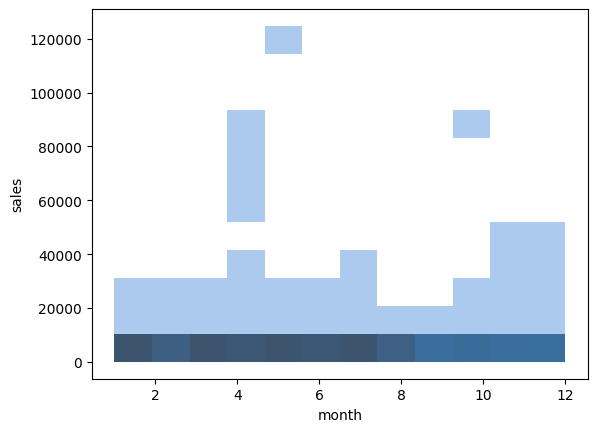

In [68]:
sns.histplot(data = df,x = 'month' , y = 'sales',bins = 12)
plt.show()

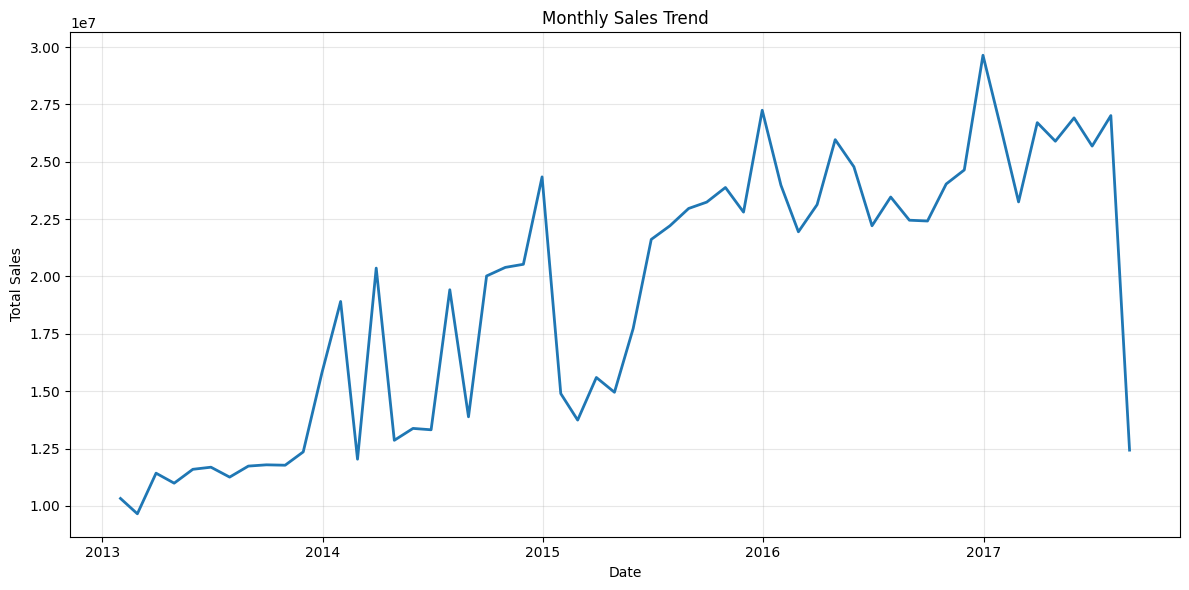

In [69]:
# Aggregate sales by month (change 'M' to 'W' for weekly, 'D' stays daily but noisier)
df_monthly = df.set_index('date').resample('M')['sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly, x='date', y='sales', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

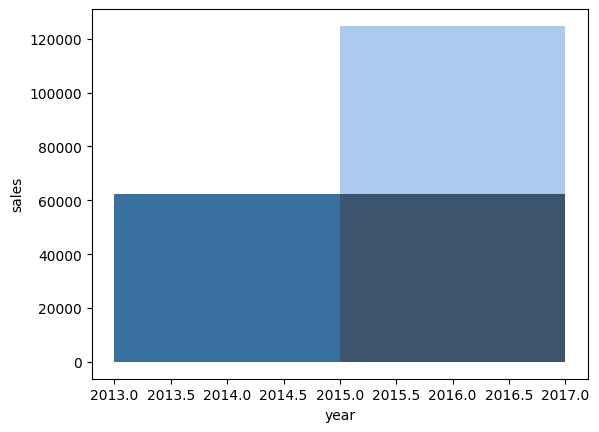

In [70]:
sns.histplot(data = df,x = 'year' , y = 'sales',bins = 2)
plt.show()

<Axes: >

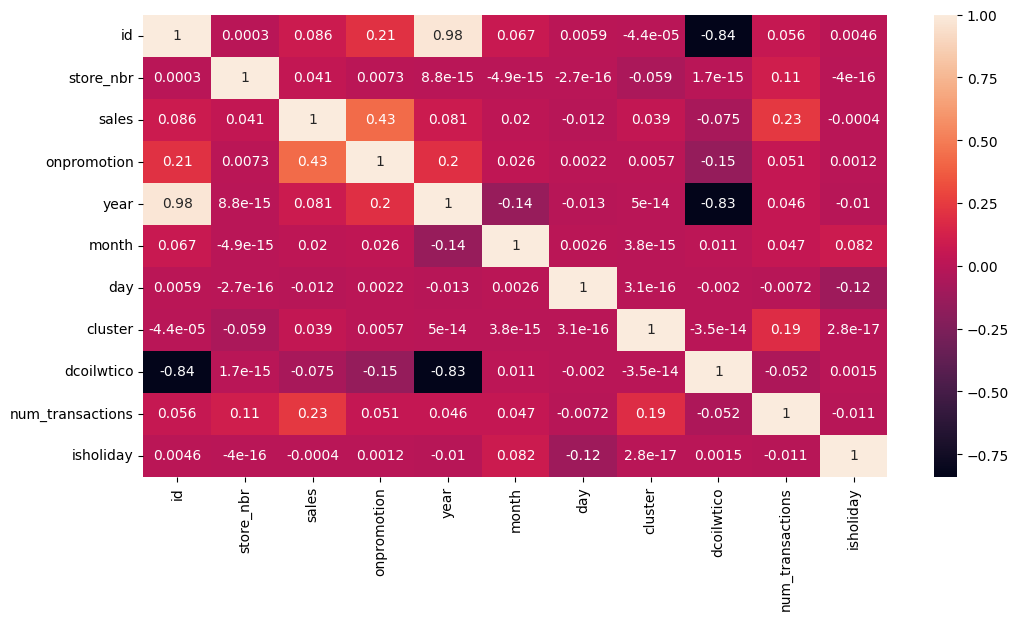

In [71]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot = True)

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

cat_col = ['family', 'city', 'state', 'type']
num_col = ['store_nbr', 'onpromotion', 'dcoilwtico', 'isholiday', 'num_transactions']

# Label-encode cluster first (it's a small-cardinality id, not one-hot worthy)
le = LabelEncoder()
df['cluster'] = le.fit_transform(df['cluster'])
known_classes = set(le.classes_)
test['cluster'] = test['cluster'].apply(lambda x: x if x in known_classes else le.classes_[0])
test['cluster'] = le.transform(test['cluster'])
num_col = num_col + ['cluster']

# Sparse OHE + scaling in one step, no dense array, no pd.concat
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=True), cat_col),
    ]
)

feature_cols = num_col + cat_col
X_train_full = preprocessor.fit_transform(df[feature_cols])
X_test_full = preprocessor.transform(test[feature_cols])
y = df['sales']

In [73]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_train_full, y, test_size=0.2, random_state=42
)

# cast to float32 to halve memory further (sparse matrices support this directly)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [74]:
# ---- training models import ----
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [75]:
# ----- evaluation function -----
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    mape = mean_absolute_percentage_error(
        y_test,
        predictions
    ) * 100

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [76]:
# ----- Linnear Regression -----
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

linear_results = evaluate_model(
    linear_model,
    x_test,
    y_test
)

MAE  : 300.68
RMSE : 719.39
R²   : 0.5836
MAPE : 35049597942883201024.00%


In [77]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state = 42)

xgb_model.fit(x_train, y_train)

xgb_results = evaluate_model(
    xgb_model,
    x_test,
    y_test
)

MAE  : 85.97
RMSE : 331.75
R²   : 0.9114
MAPE : 3477163176554557440.00%


RANDOM FOREST model taking too much time to complete.

In [79]:
# ------ Root Mean Squared Logarithmic Error -----

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)  # prevent negative predictions

    return np.sqrt(
        np.mean(
            (np.log1p(y_pred) - np.log1p(y_true)) ** 2
        )
    )

y_pred = linear_model.predict(x_test)
y_pred2 = xgb_model.predict(x_test)

score = rmsle(y_test, y_pred)
score2 = rmsle(y_test, y_pred2)

print("RMSLE Linnear:", score)
print("RMSLE XG:", score2)

RMSLE Linnear: 2.3429438032251952
RMSLE XG: 1.5281364191889841


In [84]:
# '''Let's Hyperparameter tune the XG Boost model and try to minimaise the RMSLE value '''
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import make_scorer

# # Convert your RMSLE function into a GridSearchCV scorer
# rmsle_scorer = make_scorer(
#     rmsle,
#     greater_is_better=False
# )

# param_grid = {
#     "n_estimators": [100, 200],
#     "max_depth": [3, 6],
#     "colsample_bytree": [0.8]
# }

# # GridSearchCV
# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     cv=3,
#     scoring=rmsle_scorer,
#     n_jobs=-1,
#     verbose=1
# )

# # Train
# grid_search.fit(x_train, y_train)

# # Best RMSLE
# print("\nBest CV RMSLE:")
# print(-grid_search.best_score_)

# # Best model
# best_xgb_model = grid_search.best_estimator_


# GONNA DO IT LATER

In [98]:
# --- Build submission from the test set ---

# Use the SAME preprocessor that was fit on train (in the encoding cell) —
# never re-fit it on test, only transform.
feature_cols = num_col + cat_col
X_test_input = preprocessor.transform(test[feature_cols]).astype('float32')

test_pred = xgb_model.predict(X_test_input)
test_pred = np.maximum(test_pred, 0)  # sales can't be negative

submission = pd.DataFrame({
    "id": test["id"],
    "sales": test_pred
})

submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(28512, 2)


,id,sales
0,3000888,0.000000
1,3000889,0.000000
2,3000890,239.828674
3,3000891,3959.121094
4,3000892,0.000000
